<a href="https://colab.research.google.com/github/2303A51621/SE-RA/blob/main/A4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load and Display Image
Let's load the provided screenshot and visualize it using PIL and matplotlib.

Image format: PNG
Image size: (967, 690)
Image mode: RGBA


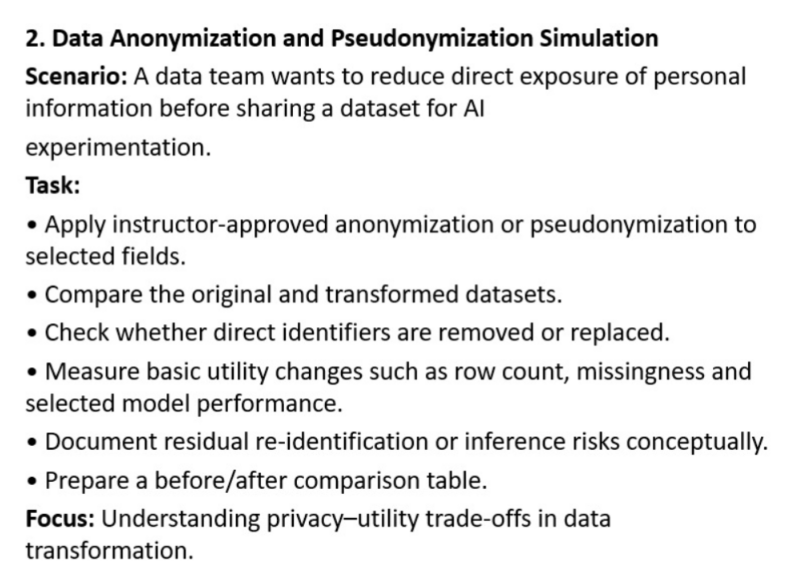

In [1]:
import matplotlib.pyplot as plt
from PIL import Image

image_path = '/content/Screenshot 2026-10-07 110133.png'

try:
    img = Image.open(image_path)
    print(f"Image format: {img.format}")
    print(f"Image size: {img.size}")
    print(f"Image mode: {img.mode}")

    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Error loading image: {e}")

### Task 1: Generate Synthetic Dataset with Sensitive Information

In [2]:
import pandas as pd
import numpy as np

# Seed for reproducibility
np.random.seed(42)

n_rows = 1000

synthetic_data = {
    'Patient_ID': [f"PAT_{1000+i}" for i in range(n_rows)],
    'Full_Name': [f"User_{i} Surname_{i}" for i in range(n_rows)],
    'Email': [f"user_{i}@example.com" for i in range(n_rows)],
    'SSN': [f"{np.random.randint(100,999)}-{np.random.randint(10,99)}-{np.random.randint(1000,9999)}" for i in range(n_rows)],
    'Age': np.random.randint(18, 80, size=n_rows),
    'ZIP_Code': np.random.randint(10000, 99999, size=n_rows),
    'Years_Experience': np.random.randint(0, 40, size=n_rows),
    'Salary': np.random.normal(50000, 15000, size=n_rows).round(2)
}

# Introduce some target relationships for predictive modeling (utility measurement)
synthetic_data['Salary'] = (25000 + (synthetic_data['Years_Experience'] * 1200) +
                            (synthetic_data['Age'] * 300) + np.random.normal(0, 5000, size=n_rows)).round(2)

df_original = pd.DataFrame(synthetic_data)
display(df_original.head())
print(f"Original dataset shape: {df_original.shape}")

,Patient_ID,Full_Name,Email,SSN,Age,ZIP_Code,Years_Experience,Salary
0,PAT_1000,User_0 Surname_0,user_0@example.com,202-61-1860,26,92152,32,76811.02
1,PAT_1001,User_1 Surname_1,user_1@example.com,370-81-6734,50,48458,14,58648.87
2,PAT_1002,User_2 Surname_2,user_2@example.com,221-92-5426,73,56169,11,56983.25
3,PAT_1003,User_3 Surname_3,user_3@example.com,558-97-9322,69,17659,39,94191.92
4,PAT_1004,User_4 Surname_4,user_4@example.com,761-62-1769,42,70614,19,55886.50


Original dataset shape: (1000, 8)


### Task 2: Apply Anonymization and Pseudonymization Techniques
We will:
1. **Redact (Drop)** the SSN column.
2. **Pseudonymize** the `Full_Name` and `Email` using cryptographic hashing (SHA-256).
3. **Generalize (Bin)** the `Age` into age-group intervals.
4. **Mask** the `ZIP_Code` to show only the first three digits (truncation).

In [3]:
import hashlib

def hash_value(val):
    return hashlib.sha256(str(val).encode('utf-8')).hexdigest()[:16]

df_transformed = df_original.copy()

# 1. Redact / Drop Direct Identifier (SSN)
df_transformed = df_transformed.drop(columns=['SSN'])

# 2. Pseudonymize Name and Email
df_transformed['Full_Name'] = df_transformed['Full_Name'].apply(hash_value)
df_transformed['Email'] = df_transformed['Email'].apply(hash_value)

# 3. Generalize Age into bins
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df_transformed['Age_Group'] = pd.cut(df_transformed['Age'], bins=age_bins, labels=age_labels)
df_transformed = df_transformed.drop(columns=['Age'])

# 4. Mask ZIP Code (Truncate to first 3 digits)
df_transformed['ZIP_Code_Masked'] = df_transformed['ZIP_Code'].astype(str).str[:3] + "xx"
df_transformed = df_transformed.drop(columns=['ZIP_Code'])

display(df_transformed.head())
print(f"Transformed dataset shape: {df_transformed.shape}")

,Patient_ID,Full_Name,Email,Years_Experience,Salary,Age_Group,ZIP_Code_Masked
0,PAT_1000,3e48ea015c601442,b244057eab2ab147,32,76811.02,25-34,921xx
1,PAT_1001,e80feccc09347f22,037af602dc00530f,14,58648.87,45-54,484xx
2,PAT_1002,cbf0cbe916fc090a,44033ba210604590,11,56983.25,65+,561xx
3,PAT_1003,6f9ec3ad777a8143,6e148d90885c5fbd,39,94191.92,65+,176xx
4,PAT_1004,09355f4bf3cf72dd,1b5f0795da3d5445,19,55886.50,35-44,706xx


Transformed dataset shape: (1000, 7)


### Task 3: Compare Datasets and Check for Direct Identifiers
Let's verify that direct identifiers like names, emails, and SSNs have been removed or successfully transformed.

In [4]:
direct_identifiers = ['Full_Name', 'Email', 'SSN']

for identifier in direct_identifiers:
    if identifier in df_transformed.columns:
        if identifier == 'SSN':
            print(f"⚠️ Error: {identifier} is still present in the dataset!")
        else:
            # Verify if values are pseudonymized/hashed and no original plaintext remains
            original_samples = set(df_original[identifier].head(10))
            transformed_samples = set(df_transformed[identifier].head(10))
            intersection = original_samples.intersection(transformed_samples)
            if len(intersection) == 0:
                print(f"✅ Success: {identifier} has been pseudonymized (No plaintext matches found in sample).")
            else:
                print(f"⚠️ Warning: Potential plaintext leak in pseudonymized {identifier}!")
    else:
        print(f"✅ Success: {identifier} has been completely removed/dropped.")

✅ Success: Full_Name has been pseudonymized (No plaintext matches found in sample).
✅ Success: Email has been pseudonymized (No plaintext matches found in sample).
✅ Success: SSN has been completely removed/dropped.


### Task 4: Measure Basic Utility Changes and Model Performance
We will evaluate the basic utility metrics (row count and missingness) and construct a regression model to predict `Salary` using both datasets to see how generalization impacts model performance.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Basic Utility metrics
row_count_orig = len(df_original)
row_count_trans = len(df_transformed)
missing_orig = df_original.isnull().sum().sum()
missing_trans = df_transformed.isnull().sum().sum()

# 2. Prepare Data for Model on Original Dataset
X_orig = df_original[['Age', 'Years_Experience']]
y_orig = df_original['Salary']
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(X_orig, y_orig, test_size=0.2, random_state=42)

model_o = LinearRegression()
model_o.fit(X_train_o, y_train_o)
preds_o = model_o.predict(X_test_o)
r2_o = r2_score(y_test_o, preds_o)
rmse_o = np.sqrt(mean_squared_error(y_test_o, preds_o))

# 3. Prepare Data for Model on Transformed Dataset (incorporating age group category)
df_model_trans = pd.get_dummies(df_transformed, columns=['Age_Group'], drop_first=True)
X_trans = df_model_trans[['Years_Experience'] + [col for col in df_model_trans.columns if 'Age_Group_' in col]]
y_trans = df_model_trans['Salary']
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_trans, y_trans, test_size=0.2, random_state=42)

model_t = LinearRegression()
model_t.fit(X_train_t, y_train_t)
preds_t = model_t.predict(X_test_t)
r2_t = r2_score(y_test_t, preds_t)
rmse_t = np.sqrt(mean_squared_error(y_test_t, preds_t))

print("--- Original Dataset Model ---")
print(f"R2 Score: {r2_o:.4f}")
print(f"RMSE: {rmse_o:.2f}")

print("\n--- Transformed Dataset Model ---")
print(f"R2 Score: {r2_t:.4f}")
print(f"RMSE: {rmse_t:.2f}")

--- Original Dataset Model ---
R2 Score: 0.8979
RMSE: 4989.13

--- Transformed Dataset Model ---
R2 Score: 0.8941
RMSE: 5080.45


### Task 5: Document Residual Risk and Prepare a Before/After Comparison Table

#### Conceptual Residual Risk Analysis
- **Re-identification Risk (Linkage Attack)**: Even though `Full_Name`, `Email`, and `SSN` are securely hashed or dropped, quasi-identifiers like `Age_Group`, `ZIP_Code_Masked`, and `Years_Experience` could still be joined with an external database to unique-match and re-identify individuals.
- **Inference Risk**: An attacker may deduce sensitive information (e.g., Salary) based on a patient's age range and experience if certain subgroups have highly predictable attributes.

In [6]:
# Prepare before/after comparison summary table
comparison_summary = {
    'Metric': [
        'Row Count',
        'Total Missing Values',
        'Direct Identifiers Exposed (e.g., SSN, Name, Email)',
        'Quasi-Identifiers Generalization Level',
        'Model R² Score (Predicting Salary)',
        'Model RMSE (Predicting Salary)',
        'Re-identification / Linkage Risk Level'
    ],
    'Before (Original Dataset)': [
        row_count_orig,
        missing_orig,
        'High (Full plaintext fields present)',
        'None (Raw continuous Age, full ZIP Code)',
        f"{r2_o:.4f}",
        f"{rmse_o:.2f}",
        'High (Complete deterministic profiles)'
    ],
    'After (Transformed Dataset)': [
        row_count_trans,
        missing_trans,
        'None (Redacted / Cryptographically hashed)',
        'High (Binned Age Groups, 3-digit Masked ZIP Code)',
        f"{r2_t:.4f}",
        f"{rmse_t:.2f}",
        'Low to Moderate (Requires linking quasi-identifiers)'
    ]
}

df_summary = pd.DataFrame(comparison_summary)
display(df_summary)

,Metric,Before (Original Dataset),After (Transformed Dataset)
0,Row Count,1000,1000
1,Total Missing Values,0,0
2,"Direct Identifiers Exposed (e.g., SSN, Name, E...",High (Full plaintext fields present),None (Redacted / Cryptographically hashed)
3,Quasi-Identifiers Generalization Level,"None (Raw continuous Age, full ZIP Code)","High (Binned Age Groups, 3-digit Masked ZIP Code)"
4,Model R² Score (Predicting Salary),0.8979,0.8941
5,Model RMSE (Predicting Salary),4989.13,5080.45
6,Re-identification / Linkage Risk Level,High (Complete deterministic profiles),Low to Moderate (Requires linking quasi-identi...
